

# PCA Face Identification

Importing required libraries:

In [1]:
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
import matplotlib.pyplot as plt

## Phase 01: Data Preparation

### Steps 1-3

- Fetching Olivetti dataset and reshaping it
- Seperating train & test dataset (first 8 images for train, last 2 for test)
- Validaitng the seperation result
- Plotting a number of raw data to see what we're gonna deal with


In [2]:
# Load the Olivetti faces dataset
olivetti = fetch_olivetti_faces()
X, y = olivetti.data, olivetti.target

# Reshape to get images per person
# Each person has 10 images, and they're consecutive
images_per_person = 10
n_people = 40

# Reshape to (40 people, 10 images, 4096 features)
X_reshaped = X.reshape(n_people, images_per_person, -1)
y_reshaped = y.reshape(n_people, images_per_person)

# Take first 8 images for training, last 2 for testing
X_train = X_reshaped[:, :8, :].reshape(-1, X.shape[1])
y_train = y_reshaped[:, :8].reshape(-1)

X_test = X_reshaped[:, 8:, :].reshape(-1, X.shape[1])
y_test = y_reshaped[:, 8:].reshape(-1)

# Verify
print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")  # 40 × 8 = 320
print(f"Test samples: {len(X_test)}")      # 40 × 2 = 80
print(f"Training people: {len(np.unique(y_train))}")  # 40
print(f"Test people: {len(np.unique(y_test))}")       # 40

# Check distribution - each person has exactly 8 train, 2 test
print(f"\nImages per person in train: {np.bincount(y_train)}")
print(f"Images per person in test: {np.bincount(y_test)}")

Total samples: 400
Training samples: 320
Test samples: 80
Training people: 40
Test people: 40

Images per person in train: [8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
 8 8 8]
Images per person in test: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2]


Plotting a few of raw data from Olivetti:

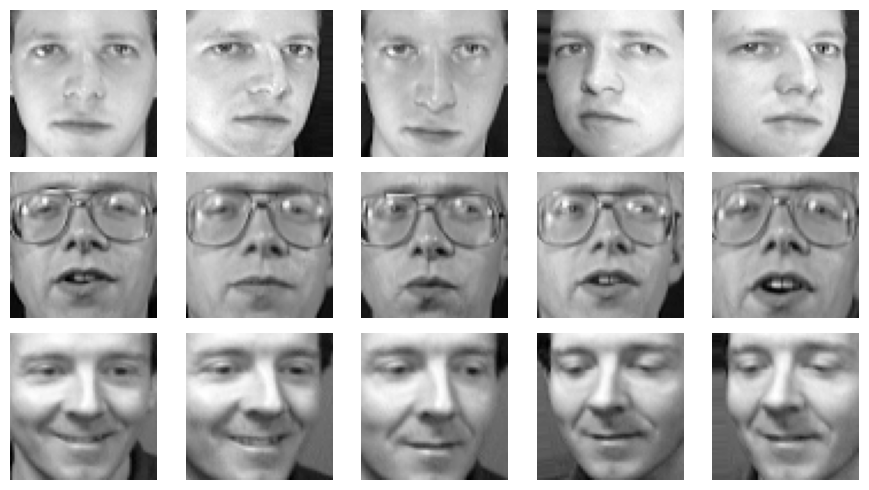

In [59]:
n_persons = 3
images_to_show = 5

fig, axes = plt.subplots(n_persons, images_to_show, figsize=(9, 5))

for person_idx in range(n_persons):
    for img_idx in range(images_to_show):
        # In X_train, each person has exactly 8 images. 
        # So Person 0 is indices 0-7, Person 1 is 8-15, etc.
        row_idx = (person_idx * 8) + img_idx
        
        # Grab the image vector and reshape to 64x64
        img = X_train[row_idx].reshape(64, 64)
        
        # Plot on the corresponding subplot
        ax = axes[person_idx, img_idx]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        
plt.tight_layout()
plt.show()

### Step 4

Computing the mean $\mu$ and Subtracting it from both $X_{train}$ and $X_{test}$ to make them centered in the feature space:

$$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i$$

In [4]:
mean_face = X_train.mean(axis=0)

X_train_centered = X_train - mean_face
X_test_centered = X_test - mean_face

Plotting the  `meanface` to see how it looks (Don't do it after midnight!)

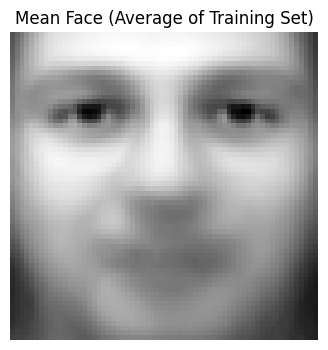

In [5]:
# Plot the Mean Face
plt.figure(figsize=(4, 4))
plt.imshow(mean_face.reshape(64, 64), cmap='gray')
plt.title("Mean Face (Average of Training Set)")
plt.axis('off')
plt.show()

Computing Variance of features to visualize which parts of faces have the most variations in this dataset:

$$\sigma^2 = \frac{1}{N-1} \sum_{i=1}^{N} (x_i - \mu)^2$$

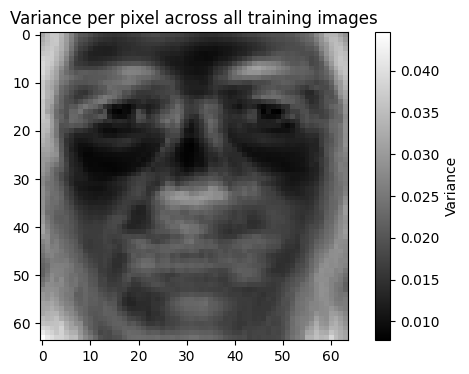

In [6]:
# Compute variance for each feature (pixel)
variances = X_train.var(axis=0)

# Visualize variance heatmap
plt.figure(figsize=(7, 4))
plt.imshow(variances.reshape(64, 64), cmap='grey')
plt.colorbar(label='Variance')
plt.title("Variance per pixel across all training images")
plt.show()

## Phase 02: Learning Subspaces

### Step 5

Making the covariance matrix for the centered $X_{train}$ matrix with $N$ samples (images):

$$S = \frac{1}{N-1}X_{c}^T \cdot X_{c}$$

In [7]:
cov_matrix = (1 / (X_train_centered.shape[0] - 1)) * (X_train_centered.T @ X_train_centered)

Eigendecomposition and sorting them so that $\lambda_1 > \lambda_2 > ... $ and $ v_1 > v_2 > ... $

In [8]:
# 1. Perform eigendecomposition (allowed by project rules)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# 2. Get the indices that would sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]

# 3. Apply the sorting to both eigenvalues and eigenvectors
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

# Verify the shapes (should be 4096 and 4096x4096)
print(f"Eigenvalues shape: {eigenvalues_sorted.shape}")
print(f"Eigenvectors shape: {eigenvectors_sorted.shape}")

Eigenvalues shape: (4096,)
Eigenvectors shape: (4096, 4096)


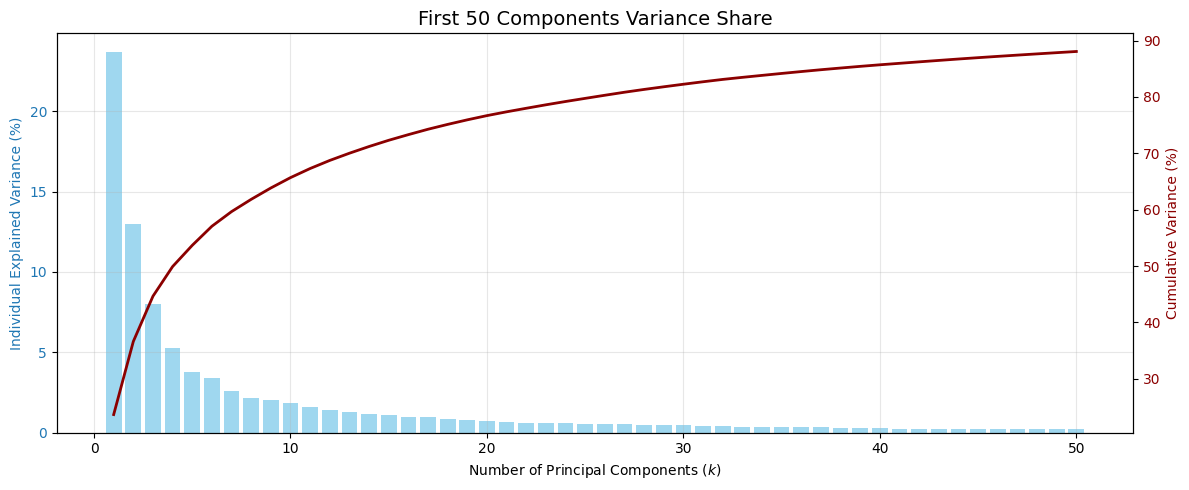

In [58]:
# 1. Calculate Explained Variance and Cumulative Variance
total_variance = np.sum(eigenvalues_sorted)
explained_variance_ratio = (eigenvalues_sorted / total_variance) * 100
cumulative_variance = np.cumsum(explained_variance_ratio)

# 2. Setup the single figure
fig, ax = plt.subplots(figsize=(12, 5))

# We only want to plot the first 50 components
k_50 = 50
x_50 = np.arange(1, k_50 + 1)

# Primary Y-axis: Bar plot for individual variance share
bars = ax.bar(x_50, explained_variance_ratio[:k_50], color='skyblue', alpha=0.8, label='Individual Variance Share')
ax.set_xlabel("Number of Principal Components ($k$)")
ax.set_ylabel("Individual Explained Variance (%)", color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')

# Secondary Y-axis: Line plot for cumulative variance
ax_twin = ax.twinx()
line = ax_twin.plot(x_50, cumulative_variance[:k_50], color='darkred', linewidth=2, label='Cumulative Variance')
ax_twin.set_ylabel("Cumulative Variance (%)", color='darkred')
ax_twin.tick_params(axis='y', labelcolor='darkred')

ax.set_title("First 50 Components Variance Share", fontsize=14, fontweight='normal')

# Combine legends from both axes into a single box
# lines_1, labels_1 = ax.get_legend_handles_labels()
# lines_2, labels_2 = ax_twin.get_legend_handles_labels()
# ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

# Add a subtle grid for easier reading
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 6
Reshaping the eigenvectors to $64*64$ matrices and plotting them to see the ***eigenfaces***:

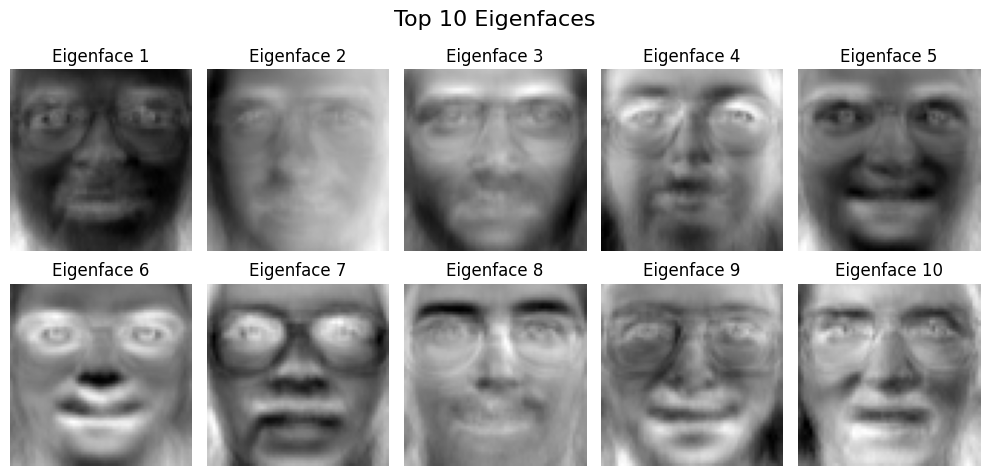

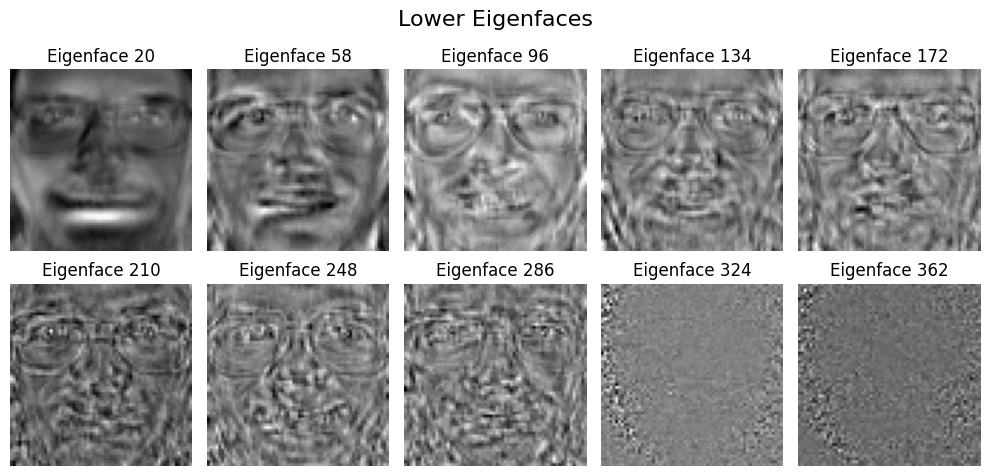

In [9]:
# ==========================================
# 1. Plot Top 12 Eigenfaces (Most Important)
# ==========================================
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
fig.suptitle("Top 10 Eigenfaces", fontsize=16)
axes = axes.flatten()

for i in range(10):
    # Extract the i-th eigenvector
    eigenvector = eigenvectors_sorted[:, i]
    eigenface = eigenvector.reshape(64, 64)
    
    # Plot it (starting at axes[i] instead of axes[i+1])
    axes[i].imshow(eigenface, cmap='gray')
    axes[i].set_title(f"Eigenface {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


# ==========================================
# 2. Plot Eigenfaces 2000 to 3800 (Step 200)
# ==========================================
fig, axes = plt.subplots(2, 5, figsize=(10, 5)) # Slightly wider figsize for 5 columns
fig.suptitle("Lower Eigenfaces", fontsize=16)
axes = axes.flatten()

# Generate the 10 indices: 
indices_to_plot = range(19, 399, 38)

for i, idx in enumerate(indices_to_plot):
    # Extract the eigenvector at the current index
    eigenvector = eigenvectors_sorted[:, idx]
    eigenface = eigenvector.reshape(64, 64)
    
    # Plot it
    axes[i].imshow(eigenface, cmap='gray')
    
    # +1 because humans count from 1, but Python indexes from 0
    axes[i].set_title(f"Eigenface {idx+1}") 
    axes[i].axis('off')


plt.tight_layout()
plt.show()

### Step 7
Reconstructing the image using $k$ eigenvectors. Testing for $k={10, 50, 150}$. the two steps are:

- **Compression:** To find out how much of each "eigenface" is inside a specific image, we calculate a weight vector,<br> as the dot product of mean-centered image vector $X_{c}$ (1, 4096) and the eigenvectors matrix $U_k$ (4096, k):

$$W = X_c \cdot U_k$$


- **Reconstruction:** To rebuild a face, We use these weights ($w_1, w_2, \dots, w_k$) as multipliers for our eigenfaces. <br> i.e we take $w_1$ amounts of Eigenface 1, add $w_2$ amounts of Eigenface 2 and so on. Then we add the `mean_face` that was subtracted before:

$$X_{reconstructed} = W \cdot U_{k}^{T} + \text{Mean Face}$$



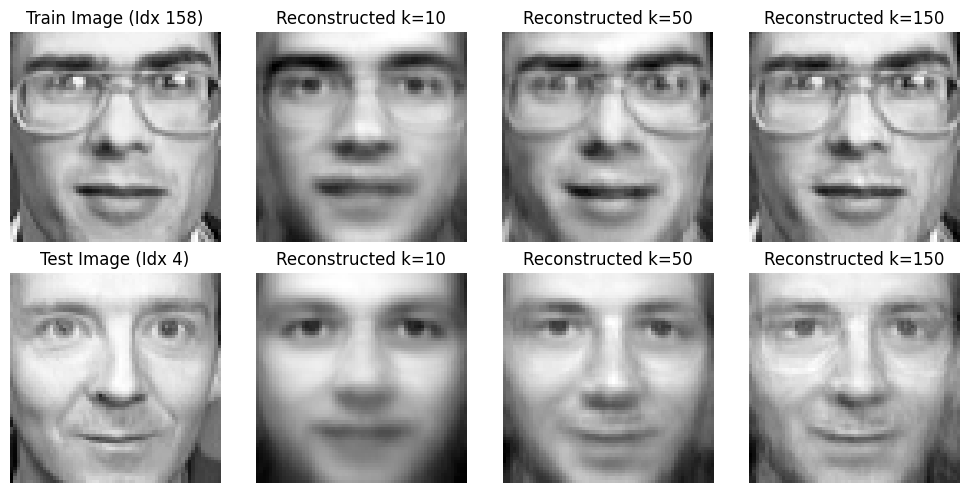

In [65]:
# Define the k values required by the task instruction
k_values = [10, 50, 150]

# Select our two images: one from Train (seen), one from Test (unseen)
images_to_reconstruct = [
    {"label": "Train Image (Idx 158)", "original": X_train[158], "centered": X_train_centered[158]},
    {"label": "Test Image (Idx 4)",    "original": X_test[4],    "centered": X_test_centered[4]}
]

# Set up a plot with 2 rows and 4 columns
fig, axes = plt.subplots(2, len(k_values) + 1, figsize=(10, 5))

for row, data in enumerate(images_to_reconstruct):
    # 1. Plot the original image in the first column
    axes[row, 0].imshow(data["original"].reshape(64, 64), cmap='gray')
    axes[row, 0].set_title(data["label"])
    axes[row, 0].axis('off')
    
    # 2. Loop through each k value, project, reconstruct, and plot
    for col, k in enumerate(k_values):
        # Select the top k eigenvectors
        U_k = eigenvectors_sorted[:, :k]
        
        # Compress: dot product of centered image and U_k
        weights = data["centered"] @ U_k
        
        # Reconstruct: dot product of weights and U_k.T, then add mean face
        reconstructed_image = (weights @ U_k.T) + mean_face
        
        # Plot the reconstructed image
        axes[row, col+1].imshow(reconstructed_image.reshape(64, 64), cmap='gray')
        axes[row, col+1].set_title(f"Reconstructed k={k}")
        axes[row, col+1].axis('off')

plt.tight_layout()
plt.show()

## Phase 03: Evaluation & Comparison

### Step 8
 
 ##### **Nearest Neighbor and accuracy**
- Do the **compression** and make a weight matrix $W = X_c \cdot U_k$ for both $X_{train}$ and $X_{test}$ in a k-D space.
- For each test image, compute the **Euclidean distance** from all training images: $\lVert W_{train} - W_{test} \lVert$
- Find the closest train image and predict it as the label
- Compute the accuracy as the ratio of true predictions to all

##### **Reconstruction Error (MSE)**
Reconstruction Error measures how much visual information is lost when you compress an image into a lower-dimensional <br> space and then attempt to rebuild it. This is calculated as a Mean Squared Error (MSE):

$$\frac{1}{N} \sum_{i=1}^{N} \left( X_{test} - X_{test \_ reconstructed} \right) ^2$$

In [11]:
# Choose a k value
k = 50
U_k = eigenvectors_sorted[:, :k]

# 2. Project both Train and Test data into k-dimensional space
W_train = X_train_centered @ U_k
W_test = X_test_centered @ U_k

# 3. Nearest Neighbor Classification
y_pred = []
for test_vector in W_test:
    # Calculate Euclidean distance between this test vector and all train vectors
    distances = np.linalg.norm(W_train - test_vector, axis=1)
    
    # Find the index of the closest training image
    closest_idx = np.argmin(distances)
    
    # Predict the label of that closest image
    y_pred.append(y_train[closest_idx])

y_pred = np.array(y_pred)

# 4. Calculate and report Accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy (k={k}): {accuracy * 100:.2f}%")

# 5. Calculate Reconstruction Error (Mean Squared Error)
X_test_reconstructed = (W_test @ U_k.T) + mean_face
mse = np.mean((X_test - X_test_reconstructed)**2)
print(f"Reconstruction Error (MSE) (k={k}): {mse:.4f}")

# 6. Find and display ALL failure cases
incorrect_indices = np.where(y_pred != y_test)[0]

if len(incorrect_indices) > 0:
    print(f"\nTotal Failures Found: {len(incorrect_indices)}")
    print("-" * 50)
    for fail_idx in incorrect_indices:
        print(f"Test Index: {fail_idx:2d} | True Identity: {y_test[fail_idx]:2d} | Predicted Identity: {y_pred[fail_idx]:2d}")
else:
    print("\nNo failures found for this k value!")

Test Accuracy (k=50): 88.75%
Reconstruction Error (MSE) (k=50): 0.0037

Total Failures Found: 9
--------------------------------------------------
Test Index:  4 | True Identity:  2 | Predicted Identity: 12
Test Index:  5 | True Identity:  2 | Predicted Identity: 22
Test Index:  7 | True Identity:  3 | Predicted Identity: 12
Test Index:  9 | True Identity:  4 | Predicted Identity: 39
Test Index: 14 | True Identity:  7 | Predicted Identity:  0
Test Index: 17 | True Identity:  8 | Predicted Identity: 39
Test Index: 18 | True Identity:  9 | Predicted Identity: 34
Test Index: 19 | True Identity:  9 | Predicted Identity:  7
Test Index: 30 | True Identity: 15 | Predicted Identity:  0


##### Failure Cases Analysis

**Visual Analysis**

First, visually check what the Nearest Neighbor algorithm saw and what it predicted:

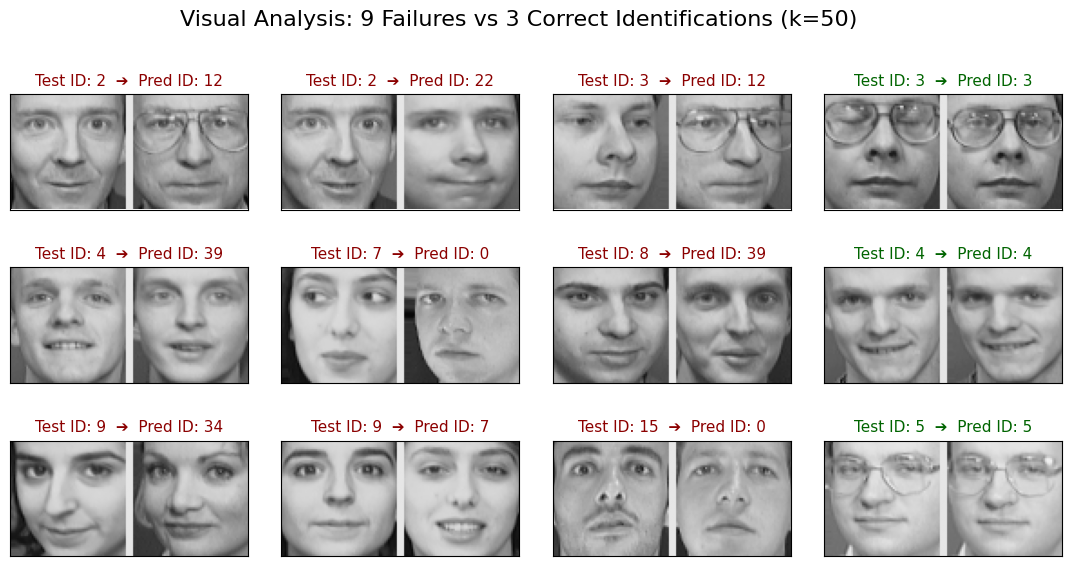

In [63]:
# -------------------------------------------------------------
# Helper: Create a single side-by-side card with a divider line
# -------------------------------------------------------------
def make_pair_card(img_left, img_right):
    """Combines Query (left) and Match (right) with a clear vertical white divider."""
    im1 = img_left.reshape(64, 64)
    im2 = img_right.reshape(64, 64)
    divider = np.ones((64, 4)) * 0.9  # 4-pixel light divider bar
    return np.hstack([im1, divider, im2])

# ==========================================
# Prep: Recalculate exact matches for k=50
# ==========================================
k = 50
U_k = eigenvectors_sorted[:, :k]
W_train = X_train_centered @ U_k
W_test = X_test_centered @ U_k

# Force recalculation of clean predictions to avoid Jupyter memory overlaps
y_pred_clean = []
for test_vector in W_test:
    distances = np.linalg.norm(W_train - test_vector, axis=1)
    closest_idx = np.argmin(distances)
    y_pred_clean.append(y_train[closest_idx])
y_pred_clean = np.array(y_pred_clean)

# Separate correct and incorrect indices
incorrect_indices = np.where(y_pred_clean != y_test)[0]
correct_indices = np.where(y_pred_clean == y_test)[0]

# Take 9 failures and 3 correct cases
cases_to_plot_fail = incorrect_indices[:9]
cases_to_plot_correct = correct_indices[4:7]

# ==========================================
# Plotting the Cases (3x4 Grid)
# ==========================================
rows = 3
cols = 4

# Slightly wider figsize to comfortably fit the 4th column
fig, axes = plt.subplots(rows, cols, figsize=(14, 2 * rows))

for r in range(rows):
    for c in range(cols):
        ax = axes[r, c]
        
        # Determine which image to pull based on the column
        if c < 3: 
            # Columns 0, 1, 2 are Failures
            list_idx = (r * 3) + c
            if list_idx < len(cases_to_plot_fail):
                test_idx = cases_to_plot_fail[list_idx]
                is_correct = False
            else:
                ax.axis('off')
                continue
        else: 
            # Column 3 is Correct Cases
            if r < len(cases_to_plot_correct):
                test_idx = cases_to_plot_correct[r]
                is_correct = True
            else:
                ax.axis('off')
                continue
                
        # Recalculate exact nearest neighbor to show the ACTUAL image 
        test_vector = W_test[test_idx]
        distances = np.linalg.norm(W_train - test_vector, axis=1)
        train_idx = np.argmin(distances)
        
        # Create the visual card
        card = make_pair_card(X_test[test_idx], X_train[train_idx])
        
        ax.axis('on')
        ax.imshow(card, cmap='gray', vmin=0.0, vmax=1.0)
        
        # Format the title based on success/failure
        if is_correct:
            ax.set_title(
                f"Test ID: {y_test[test_idx]}  ➔  Pred ID: {y_train[train_idx]}",
                fontsize=11, color='darkgreen', pad=6
            )
        else:
            ax.set_title(
                f"Test ID: {y_test[test_idx]}  ➔  Pred ID: {y_train[train_idx]}",
                fontsize=11, color='darkred', pad=6
            )
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Visual Analysis: 9 Failures vs 3 Correct Identifications (k=50)", fontsize=16, y=1.02, fontweight='normal')
plt.subplots_adjust(wspace=0.0, hspace=0.5)
plt.show()

**Distance Gap Analysis**

To see exactly how badly the model missed the correct label (true ID):

Generating Distance Gap Bar Plot...


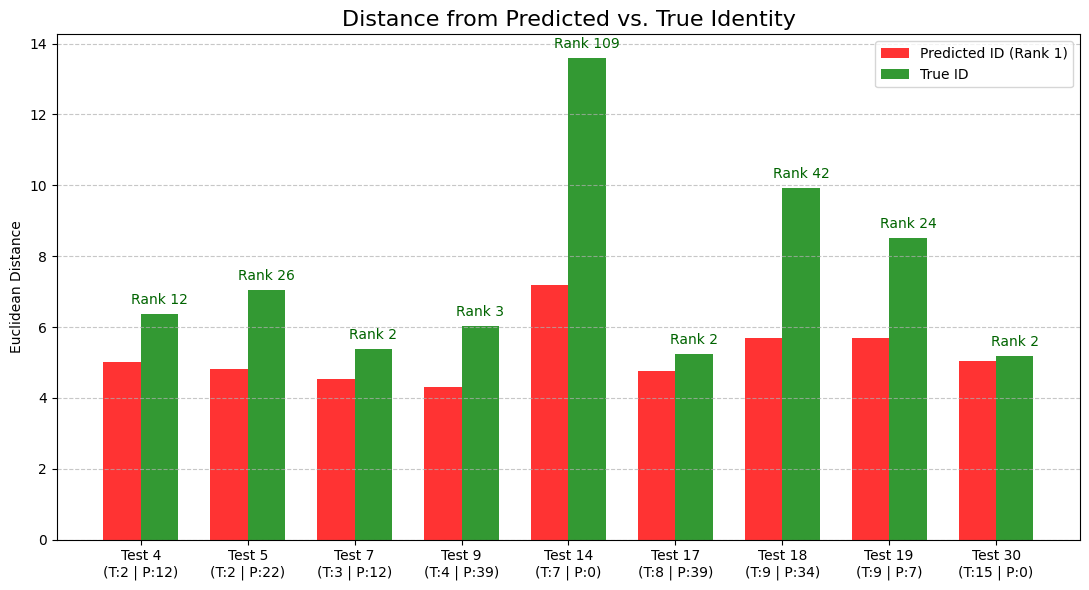

In [68]:
k = 50
U_k = eigenvectors_sorted[:, :k]
W_train = X_train_centered @ U_k
W_test = X_test_centered @ U_k
# ---------------------------------------------------

print("Generating Distance Gap Bar Plot...")

# Storage for our plot data
labels = []
pred_distances = []
true_distances = []
true_ranks = []

# 1. Extract the data for all failure cases
for fail_idx in incorrect_indices:
    true_id = y_test[fail_idx]
    
    # Now both vectors are guaranteed to be k=50
    test_vector = W_test[fail_idx] 
    
    # Calculate Euclidean distances to all training images
    distances = np.linalg.norm(W_train - test_vector, axis=1)
    sorted_indices = np.argsort(distances)
    
    # Rank 1 (The Wrong Prediction)
    rank1_idx = sorted_indices[0]
    pred_id = y_train[rank1_idx]
    pred_distances.append(distances[rank1_idx])
    
    # The True Identity
    true_rank_idx = np.where(y_train[sorted_indices] == true_id)[0][0]
    true_distances.append(distances[sorted_indices[true_rank_idx]])
    true_ranks.append(true_rank_idx + 1)
    
    # Create a label for the x-axis
    labels.append(f"Test {fail_idx}\n(T:{true_id} | P:{pred_id})")

# ==========================================
# 2. Plotting the Grouped Bar Chart
# ==========================================
x = np.arange(len(incorrect_indices))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(11, 6))
rects1 = ax.bar(x - width/2, pred_distances, width, label='Predicted ID (Rank 1)', color='red', alpha=0.8)
rects2 = ax.bar(x + width/2, true_distances, width, label='True ID', color='green', alpha=0.8)

# Add some text for labels, title and custom x-axis tick labels
ax.set_ylabel('Euclidean Distance')
ax.set_title('Distance from Predicted vs. True Identity', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add the True Rank number on top of the green bars
for i in range(len(x)):
    ax.text(x[i] + width/2, true_distances[i] + 0.2, 
            f"Rank {true_ranks[i]}", 
            ha='center', va='bottom', fontsize=10, color='darkgreen')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Performance Metrics
To sea how *accuracy* and *Reconstruction Error (MSE)* change as $k$ increaes.

Calculating metrics for K=1 to 320. This might take a few seconds...


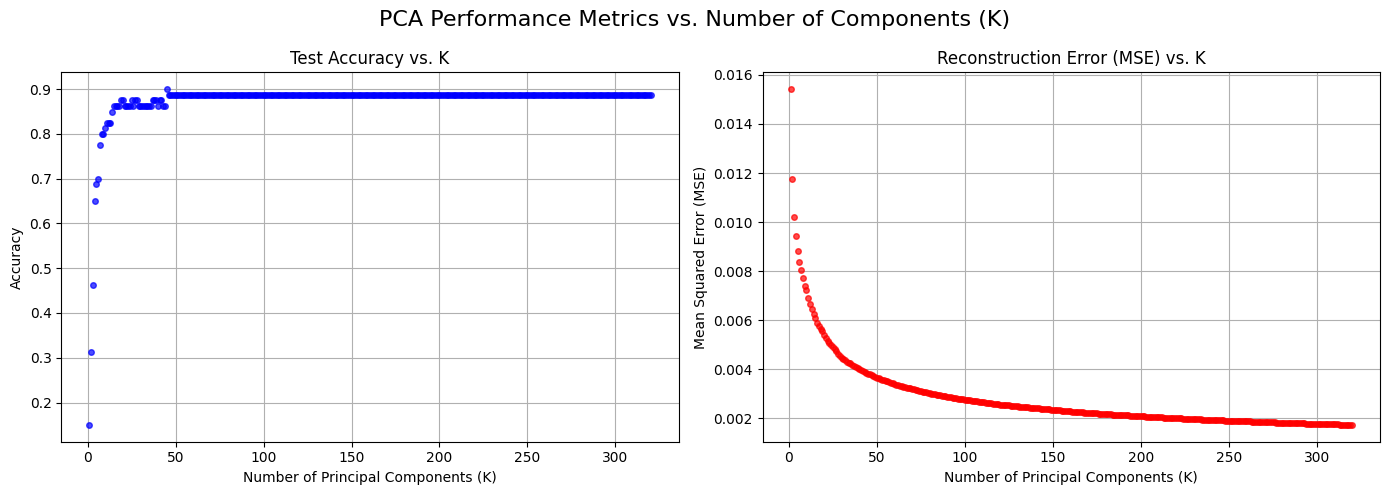

In [34]:

# We want to test K values from 1 up to 320
k_values = range(1, 321)

accuracies = []
reconstruction_errors = []

print("Calculating metrics for K=1 to 320. This might take a few seconds...")

for k in k_values:
    # 1. Slice top k eigenvectors
    U_k = eigenvectors_sorted[:, :k]
    
    # 2. Project Data into k-dimensional space
    W_train = X_train_centered @ U_k
    W_test = X_test_centered @ U_k
    
    # 3. Nearest Neighbor Classification
    y_pred = []
    for test_vector in W_test:
        distances = np.linalg.norm(W_train - test_vector, axis=1)
        closest_idx = np.argmin(distances)
        y_pred.append(y_train[closest_idx])
        
    # 4. Calculate Accuracy
    acc = np.mean(np.array(y_pred) == y_test)
    accuracies.append(acc)
    
    # 5. Calculate Reconstruction Error (MSE)
    X_test_reconstructed = (W_test @ U_k.T) + mean_face
    mse = np.mean((X_test - X_test_reconstructed)**2)
    reconstruction_errors.append(mse)

# ==========================================
# Plotting the Results
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA Performance Metrics vs. Number of Components (K)", fontsize=16)

# Plot 1: Accuracy vs K
ax1.plot(k_values, accuracies, marker='o', linestyle='none', markersize=4, color='blue', alpha=0.7)
ax1.set_title("Test Accuracy vs. K")
ax1.set_xlabel("Number of Principal Components (K)")
ax1.set_ylabel("Accuracy")
ax1.grid(True)


# Plot 2: Reconstruction Error vs K
ax2.plot(k_values, reconstruction_errors, marker='o', linestyle='none', markersize=4, color='red', alpha=0.7)
ax2.set_title("Reconstruction Error (MSE) vs. K")
ax2.set_xlabel("Number of Principal Components (K)")
ax2.set_ylabel("Mean Squared Error (MSE)")
ax2.grid(True)

plt.tight_layout()
plt.show()

### Step 9
Comparison with SVD.
- Use SVD to decompose $X_{train}$ matrix to $X_{train} = U \Sigma V^T$
- Here the matrix $V^T$ is our eigenfaces
- Next steps are the same. Compress, reconstruct, and compute the reconstruction MSE.
- Compare SVD's reconstruction MSE with PCA's reconstruction MSE

In [35]:
# 1. Perform SVD directly on the centered training data
# full_matrices=False is computationally efficient
U, S, Vt = np.linalg.svd(X_train_centered, full_matrices=False)

# 2. Extract the top k components 
# (The rows of Vt are the principal components, so we transpose it)
U_k_svd = Vt.T[:, :k]

# 3. Reconstruct the test data using the SVD components
W_test_svd = X_test_centered @ U_k_svd
X_test_reconstructed_svd = (W_test_svd @ U_k_svd.T) + mean_face

# 4. Compare the Reconstructions (Eigh vs SVD)
# We calculate the Mean Squared Error between the two reconstructed sets
diff = np.mean((X_test_reconstructed - X_test_reconstructed_svd)**2)

print(f"Difference between Eigh and SVD reconstruction: {diff:.10f}")
if diff < 1e-5:
    print("Success! Both methods lead to the same subspace and reconstructions.")

Difference between Eigh and SVD reconstruction: 0.0000006276
Success! Both methods lead to the same subspace and reconstructions.


## Special Task (Team 05)

Testing how much the model is robust when subjected to noise or masking (occlusion).

### Noise Robustness
We evaluate the model against three real-world image noises:

--- 
##### **1. Gaussian Noise**

Simulates random static from bad lighting or poor camera sensors, creating a grainy look.<br>
It adds a random value drawn from a normal distribution to every pixel.

$$X_{noisy} = X + \mathcal{N}(\mu, \sigma)$$

*   $X$: Original pixel matrix.
*   $\mathcal{N}$: Normal distribution.
---
##### **2. Salt & Pepper Noise**
Simulates dead camera pixels or digital transmission errors by overwriting random pixels with pure white or black data. <br>
It forcefully overwrites a probability ($p$) of pixels. For a random number $r$ generated for each pixel:

*   If $r < \frac{p}{2}$, the pixel becomes $0.0$ (Black).
*   If $\frac{p}{2} \le r < p$, the pixel becomes $1.0$ (White).
*   If $r \ge p$, the pixel remains its original value $x$.

---
##### **3. Poisson (Shot) Noise**

Simulates the quantum nature of light in dark environments. The noise amount depends on original brightness, affecting brighter areas more. <br>
The variance of this noise is directly tied to expected brightness.

$$X_{noisy} = \frac{\mathcal{P}(X \cdot peak)}{peak}$$

*   $\mathcal{P}$: Poisson distribution returning a random count.
*   $peak$: Scaling factor to control intensity. 

*(Note: Because our dataset uses normalized decimals between 0.0 and 1.0, the pixels are first multiplied by the $peak$ to scale them into pseudo-integers <br> before the Poisson distribution is applied, and then divided by the $peak$ to shrink the image back down to its proper scale.)*

---


Now, we compare the accuracy and MSE for each noise applied, for a fixed $k = 50$ :

In [108]:
# A reusable function to evaluate any distorted test set
def evaluate_noisy_model(X_test_noisy, k=50):
    # 1. Center the NOISY test data using the CLEAN training mean
    X_test_noisy_centered = X_test_noisy - mean_face
    
    # 2. Get top k eigenvectors (learned from clean data)
    U_k = eigenvectors_sorted[:, :k]
    
    # 3. Project both clean train and noisy test data
    W_train = X_train_centered @ U_k
    W_test_noisy = X_test_noisy_centered @ U_k
    
    # 4. Nearest Neighbor Classification
    y_pred = []
    for test_vector in W_test_noisy:
        distances = np.linalg.norm(W_train - test_vector, axis=1)
        closest_idx = np.argmin(distances)
        y_pred.append(y_train[closest_idx])
        
    accuracy = np.mean(np.array(y_pred) == y_test)
    
    # 5. Reconstruction Error (MSE) compared to the ORIGINAL clean test images
    X_test_reconstructed = (W_test_noisy @ U_k.T) + mean_face
    mse = np.mean((X_test - X_test_reconstructed)**2)
    
    return accuracy, mse

print("Baseline (Clean Data) for k = 50")
print("Accuracy: 88.75% | MSE: 0.0037")
print("-" * 40)

# ==========================================
# Set Master Intensity (0.0 to 1.0 Scale)
# ==========================================
intensity = 0.10
print(f"Applying High Noise Intensity: {intensity}")
print("-" * 40)

# 1. Gaussian Noise (Intensity = Standard Deviation)
gaussian_noise = np.random.normal(loc=0.0, scale=intensity, size=X_test.shape)
X_test_gaussian = np.clip(X_test + gaussian_noise, 0., 1.)

acc_g, mse_g = evaluate_noisy_model(X_test_gaussian)
print(f"Gaussian Noise    -> Accuracy: {acc_g*100:.2f}% | MSE: {mse_g:.4f}")

# 2. Salt-and-Pepper Noise (Intensity = % of pixels destroyed)
X_test_sp = X_test.copy()
random_matrix = np.random.random(X_test.shape)
X_test_sp[random_matrix < (intensity / 2)] = 0.0 # Pepper (Black)
X_test_sp[(random_matrix >= (intensity / 2)) & (random_matrix < intensity)] = 1.0 # Salt (White)

acc_sp, mse_sp = evaluate_noisy_model(X_test_sp)
print(f"Salt & Pepper     -> Accuracy: {acc_sp*100:.2f}% | MSE: {mse_sp:.4f}")

# 3. Poisson Noise (Intensity mapped to inverse peak)
peak = max(1.0, 1.0 / intensity)
X_test_poisson = np.random.poisson(X_test * peak) / peak
X_test_poisson = np.clip(X_test_poisson, 0., 1.)

acc_p, mse_p = evaluate_noisy_model(X_test_poisson)
print(f"Poisson Noise     -> Accuracy: {acc_p*100:.2f}% | MSE: {mse_p:.4f}")

Baseline (Clean Data) for k = 50
Accuracy: 88.75% | MSE: 0.0037
----------------------------------------
Applying High Noise Intensity: 0.1
----------------------------------------
Gaussian Noise    -> Accuracy: 90.00% | MSE: 0.0038
Salt & Pepper     -> Accuracy: 87.50% | MSE: 0.0043
Poisson Noise     -> Accuracy: 88.75% | MSE: 0.0045


Visualizing what each type of noise do to test images:

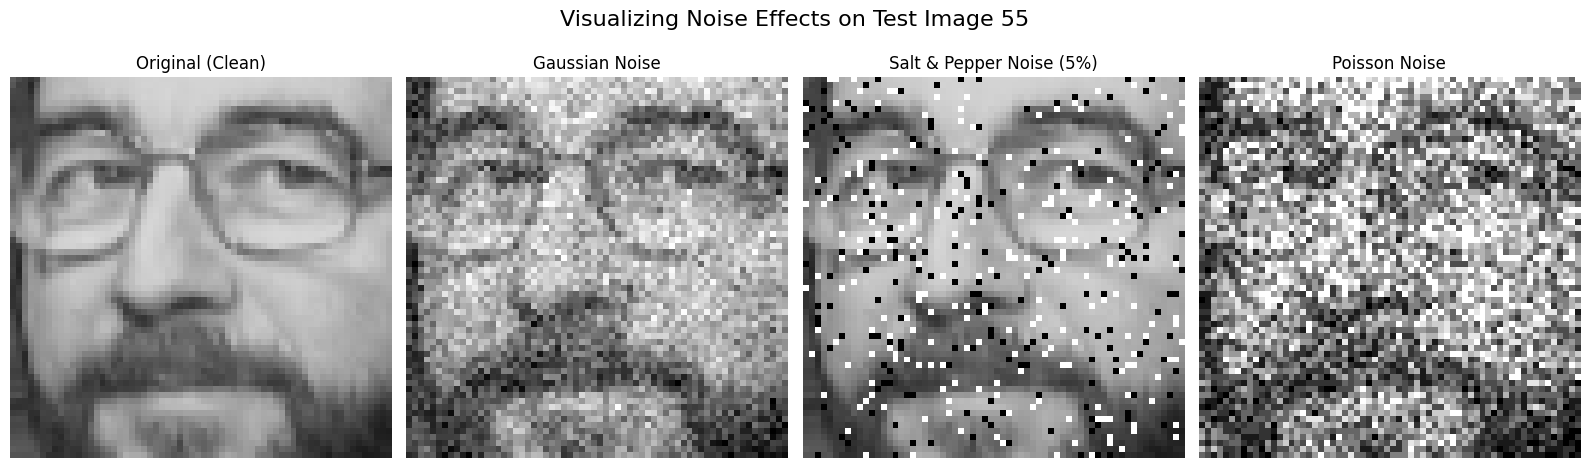

In [109]:
# Let's use test index 4, which was a known tricky image for the model
test_idx = 55

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle(f"Visualizing Noise Effects on Test Image {test_idx}", fontsize=16)

# 1. Original Clean Test Image
axes[0].imshow(X_test[test_idx].reshape(64, 64), cmap='gray', vmin=0.0, vmax=1.0)
axes[0].set_title("Original (Clean)")
axes[0].axis('off')

# 2. Gaussian Noise
axes[1].imshow(X_test_gaussian[test_idx].reshape(64, 64), cmap='gray', vmin=0.0, vmax=1.0)
axes[1].set_title("Gaussian Noise")
axes[1].axis('off')

# 3. Salt & Pepper Noise
axes[2].imshow(X_test_sp[test_idx].reshape(64, 64), cmap='gray', vmin=0.0, vmax=1.0)
axes[2].set_title("Salt & Pepper Noise (5%)")
axes[2].axis('off')

# 4. Poisson Noise
axes[3].imshow(X_test_poisson[test_idx].reshape(64, 64), cmap='gray', vmin=0.0, vmax=1.0)
axes[3].set_title("Poisson Noise")
axes[3].axis('off')

plt.tight_layout()
plt.show()

Evaluating model robustness across increasing noise intensities...


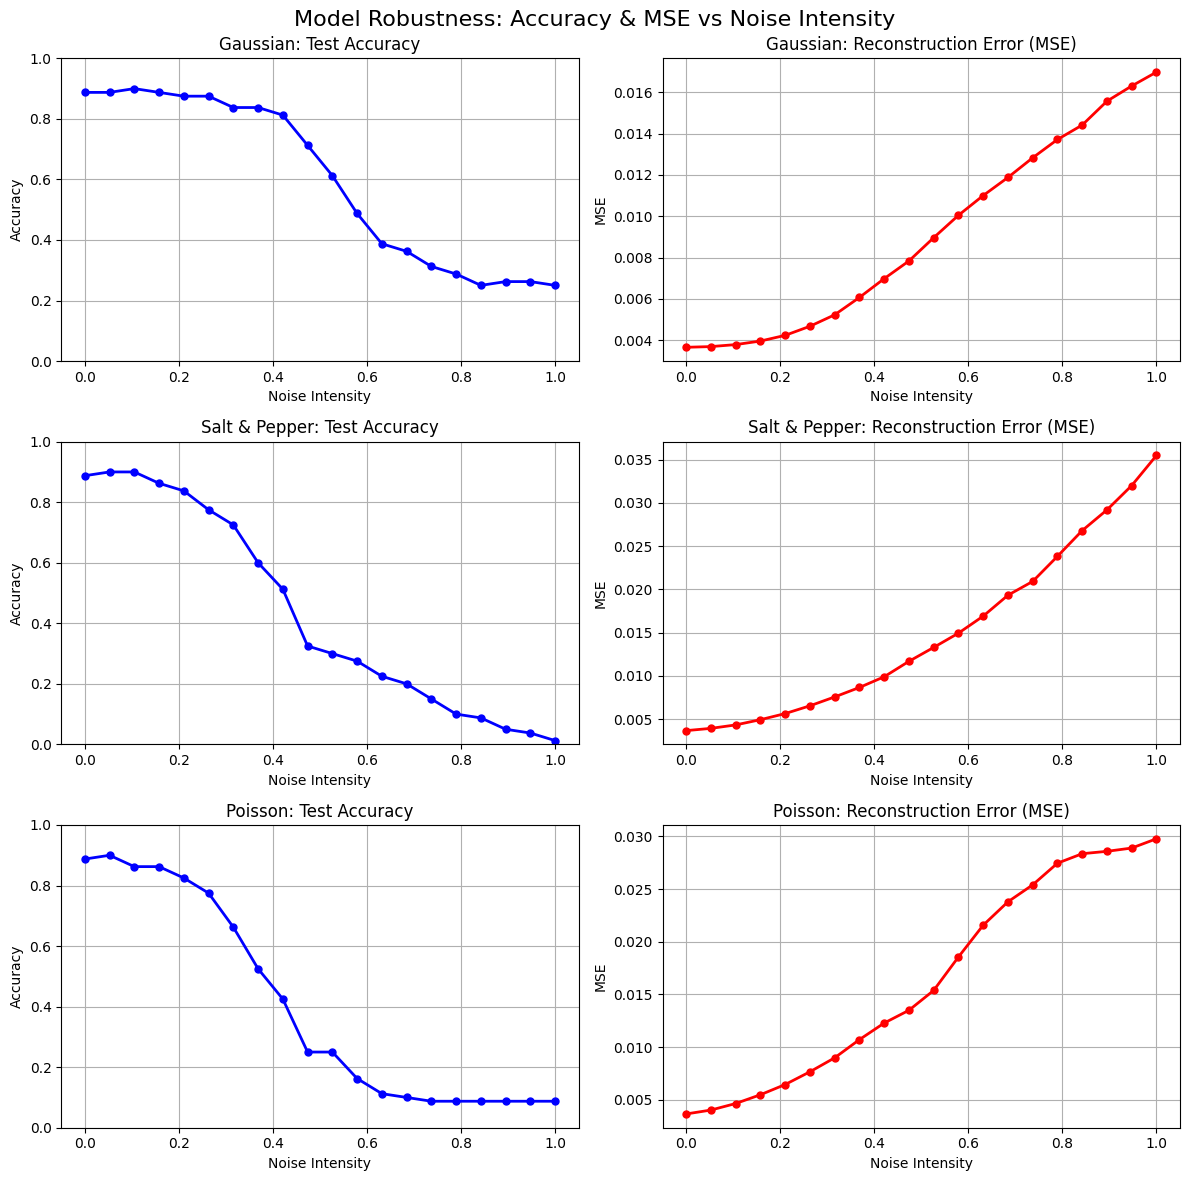

In [77]:
# Define intensity steps (0.0 means clean image, 0.5 means heavy noise)
intensities = np.linspace(0.0, 1.0, 20)

# Storage lists for the metrics
acc_gaussian, mse_gaussian = [], []
acc_sp, mse_sp = [], []
acc_poisson, mse_poisson = [], []

print("Evaluating model robustness across increasing noise intensities...")

for intensity in intensities:
    # 1. Gaussian Noise (intensity = standard deviation)
    gauss_noise = np.random.normal(loc=0.0, scale=intensity, size=X_test.shape)
    X_test_g = np.clip(X_test + gauss_noise, 0., 1.)
    a_g, m_g = evaluate_noisy_model(X_test_g, k=50)
    acc_gaussian.append(a_g)
    mse_gaussian.append(m_g)
    
    # 2. Salt & Pepper Noise (intensity = proportion of pixels overwritten)
    X_test_sp = X_test.copy()
    random_matrix = np.random.random(X_test.shape)
    X_test_sp[random_matrix < (intensity / 2)] = 0.0
    X_test_sp[(random_matrix >= (intensity / 2)) & (random_matrix < intensity)] = 1.0
    a_sp, m_sp = evaluate_noisy_model(X_test_sp, k=50)
    acc_sp.append(a_sp)
    mse_sp.append(m_sp)
    
    # 3. Poisson Noise 
    # Poisson intensity increases as the 'peak' value decreases.
    if intensity == 0.0:
        a_p, m_p = evaluate_noisy_model(X_test, k=50)
    else:
        # Map intensity (0.05 -> 1.0) to a peak value (20.0 -> 1.0)
        peak = max(1.0, 1.0 / intensity)
        X_test_p = np.random.poisson(X_test * peak) / peak
        X_test_p = np.clip(X_test_p, 0., 1.)
        a_p, m_p = evaluate_noisy_model(X_test_p, k=50)
        
    acc_poisson.append(a_p)
    mse_poisson.append(m_p)

# ==========================================
# Plotting the Results
# ==========================================
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle("Model Robustness: Accuracy & MSE vs Noise Intensity", fontsize=16)

def plot_metrics(ax_acc, ax_mse, intensity_x, acc_y, mse_y, title):
    # Accuracy Plot
    ax_acc.plot(intensity_x, acc_y, marker='o', color='blue', linewidth=2, markersize=5)
    ax_acc.set_title(f"{title}: Test Accuracy")
    ax_acc.set_xlabel("Noise Intensity")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_ylim(0, 1.0) # Lock accuracy y-axis from 0% to 100%
    ax_acc.grid(True)
    
    # MSE Plot
    ax_mse.plot(intensity_x, mse_y, marker='o', color='red', linewidth=2, markersize=5)
    ax_mse.set_title(f"{title}: Reconstruction Error (MSE)")
    ax_mse.set_xlabel("Noise Intensity")
    ax_mse.set_ylabel("MSE")
    ax_mse.grid(True)

# Generate the 6 subplots
plot_metrics(axes[0,0], axes[0,1], intensities, acc_gaussian, mse_gaussian, "Gaussian")
plot_metrics(axes[1,0], axes[1,1], intensities, acc_sp, mse_sp, "Salt & Pepper")
plot_metrics(axes[2,0], axes[2,1], intensities, acc_poisson, mse_poisson, "Poisson")

plt.tight_layout()
plt.show()

### Mask (Occlusion) Robustness

We evaluate how well the model handles missing information by applying occlusion masks. Because matrix operations cannot process null values, we simulate occlusion by overwriting specific rectangular regions with pure black pixels (0.0).

#### Fixed Masks

Simulates physical obstructions over the face, such as wearing sunglasses, a medical mask, or a severe profile shadow falling across the lens. <br>
We use NumPy array slicing to select specific two-dimensional regions based on basic facial proportions and directly overwrite those pixels to 0.0.

*   **Sunglasses Mask:** Targets the eyes and eyebrows by overwriting rows 15 to 35.
*   **Medical Mask:** Targets the mouth, nose, and chin by overwriting rows 35 to 64.
*   **Half-Face Mask:** Destroys horizontal symmetry by overwriting the first 32 columns across all rows.

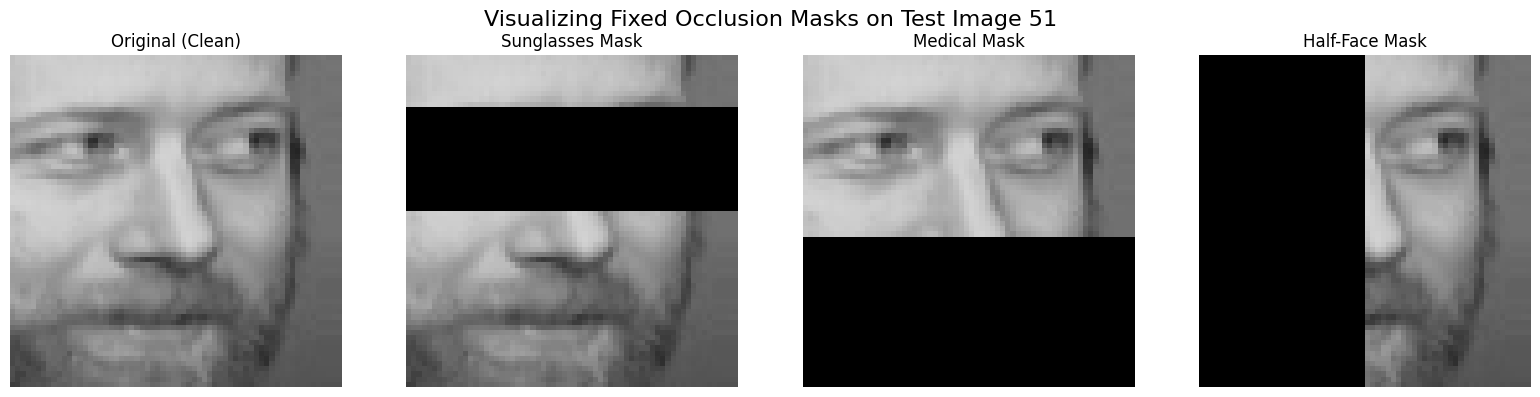

In [88]:
test_idx = 51
original_img = X_test[test_idx].reshape(64, 64)

# 1. The "Sunglasses" Mask (Blocking the eyes)
# We overwrite rows 15 through 35 across all columns
img_sunglasses = original_img.copy()
img_sunglasses[10:30, :] = 0.0 

# 2. The "Medical Mask" (Blocking the mouth and chin)
# We overwrite rows 35 to the bottom (64) across all columns
img_medical = original_img.copy()
img_medical[35:64, :] = 0.0 

# 3. The "Half-Face" Mask (Simulating a severe profile shadow)
# We overwrite the first 32 columns across all rows
img_half = original_img.copy()
img_half[:, :32] = 0.0 

# ==========================================
# Plotting the Masks
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f"Visualizing Fixed Occlusion Masks on Test Image {test_idx}", fontsize=16)

# We use vmin=0.0 and vmax=1.0 to prevent the grey-skin bug we fixed earlier!
axes[0].imshow(original_img, cmap='gray', vmin=0.0, vmax=1.0)
axes[0].set_title("Original (Clean)")
axes[0].axis('off')

axes[1].imshow(img_sunglasses, cmap='gray', vmin=0.0, vmax=1.0)
axes[1].set_title("Sunglasses Mask")
axes[1].axis('off')

axes[2].imshow(img_medical, cmap='gray', vmin=0.0, vmax=1.0)
axes[2].set_title("Medical Mask")
axes[2].axis('off')

axes[3].imshow(img_half, cmap='gray', vmin=0.0, vmax=1.0)
axes[3].set_title("Half-Face Mask")
axes[3].axis('off')

plt.tight_layout()
plt.show()

Plotting how the accuracy and MSE change with different $k$'s for each of fixed masks:

In [97]:
# 1. Create the masked datasets for the ENTIRE test set (80 images)
X_test_sunglasses = X_test.copy().reshape(-1, 64, 64)
X_test_sunglasses[:, 15:35, :] = 0.0
X_test_sunglasses = X_test_sunglasses.reshape(-1, 4096)

X_test_medical = X_test.copy().reshape(-1, 64, 64)
X_test_medical[:, 35:64, :] = 0.0
X_test_medical = X_test_medical.reshape(-1, 4096)

X_test_half = X_test.copy().reshape(-1, 64, 64)
X_test_half[:, :, :32] = 0.0
X_test_half = X_test_half.reshape(-1, 4096)

# 2. Setup storage for the evaluation loop
k_values = range(1, 321)
acc_baseline, mse_baseline = [], []
acc_sunglasses, mse_sunglasses = [], []
acc_medical, mse_medical = [], []
acc_half, mse_half = [], []

# Ensure training data is centered
X_train_centered = X_train - mean_face

print("Evaluating all masks across K=1 to 320. This will take a few moments...")

# Reusable function to calculate BOTH accuracy and MSE
def evaluate_mask(X_test_masked, U_k, W_train):
    # Center the masked test data using the clean training mean
    X_test_masked_centered = X_test_masked - mean_face
    
    # Project into k-dimensional space
    W_test = X_test_masked_centered @ U_k
    
    # Calculate Accuracy
    y_pred = []
    for test_vector in W_test:
        distances = np.linalg.norm(W_train - test_vector, axis=1)
        closest_idx = np.argmin(distances)
        y_pred.append(y_train[closest_idx])
    accuracy = np.mean(np.array(y_pred) == y_test)
    
    # Calculate MSE compared to the ORIGINAL CLEAN test images
    X_test_reconstructed = (W_test @ U_k.T) + mean_face
    mse = np.mean((X_test - X_test_reconstructed)**2)
    
    return accuracy, mse

# 3. Loop through all K values
for k in k_values:
    U_k = eigenvectors_sorted[:, :k]
    W_train = X_train_centered @ U_k
    
    a, m = evaluate_mask(X_test, U_k, W_train)
    acc_baseline.append(a); mse_baseline.append(m)
    
    a, m = evaluate_mask(X_test_sunglasses, U_k, W_train)
    acc_sunglasses.append(a); mse_sunglasses.append(m)
    
    a, m = evaluate_mask(X_test_medical, U_k, W_train)
    acc_medical.append(a); mse_medical.append(m)
    
    a, m = evaluate_mask(X_test_half, U_k, W_train)
    acc_half.append(a); mse_half.append(m)

Evaluating all masks across K=1 to 320. This will take a few moments...


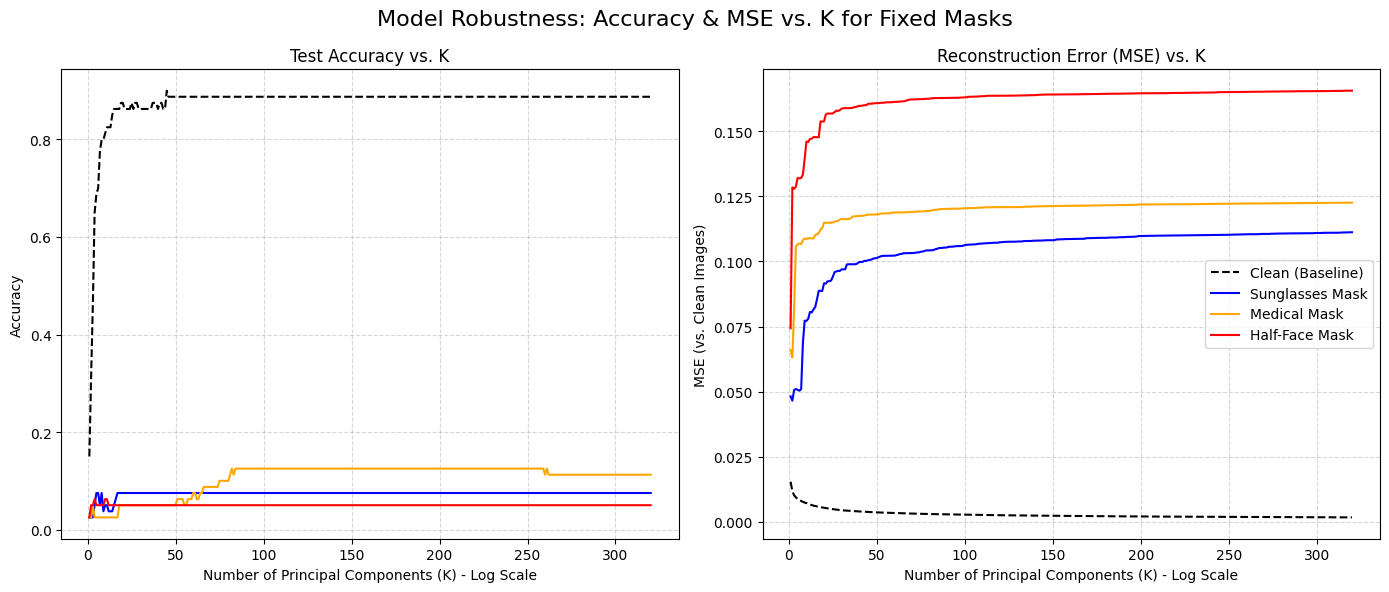

In [98]:
# ==========================================
# Plotting the Results
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Model Robustness: Accuracy & MSE vs. K for Fixed Masks", fontsize=16)

# --- Plot 1: Accuracy ---
ax1.plot(k_values, acc_baseline, label='Clean (Baseline)', color='black', linestyle='--')
ax1.plot(k_values, acc_sunglasses, label='Sunglasses Mask', color='blue')
ax1.plot(k_values, acc_medical, label='Medical Mask', color='orange')
ax1.plot(k_values, acc_half, label='Half-Face Mask', color='red')

ax1.set_title("Test Accuracy vs. K")
ax1.set_xlabel("Number of Principal Components (K) - Log Scale")
ax1.set_ylabel("Accuracy")
# ax1.set_xscale('log')
# ax1.xaxis.set_major_formatter(ScalarFormatter()) 
ax1.grid(True, which="both", ls="--", alpha=0.5)

# --- Plot 2: MSE ---
ax2.plot(k_values, mse_baseline, label='Clean (Baseline)', color='black', linestyle='--')
ax2.plot(k_values, mse_sunglasses, label='Sunglasses Mask', color='blue')
ax2.plot(k_values, mse_medical, label='Medical Mask', color='orange')
ax2.plot(k_values, mse_half, label='Half-Face Mask', color='red')

ax2.set_title("Reconstruction Error (MSE) vs. K")
ax2.set_xlabel("Number of Principal Components (K) - Log Scale")
ax2.set_ylabel("MSE (vs. Clean Images)")
# ax2.set_xscale('log')
# ax2.xaxis.set_major_formatter(ScalarFormatter())
ax2.legend()
ax2.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

Visualizing how a test image is reconstructed while subjected to fixed masks:

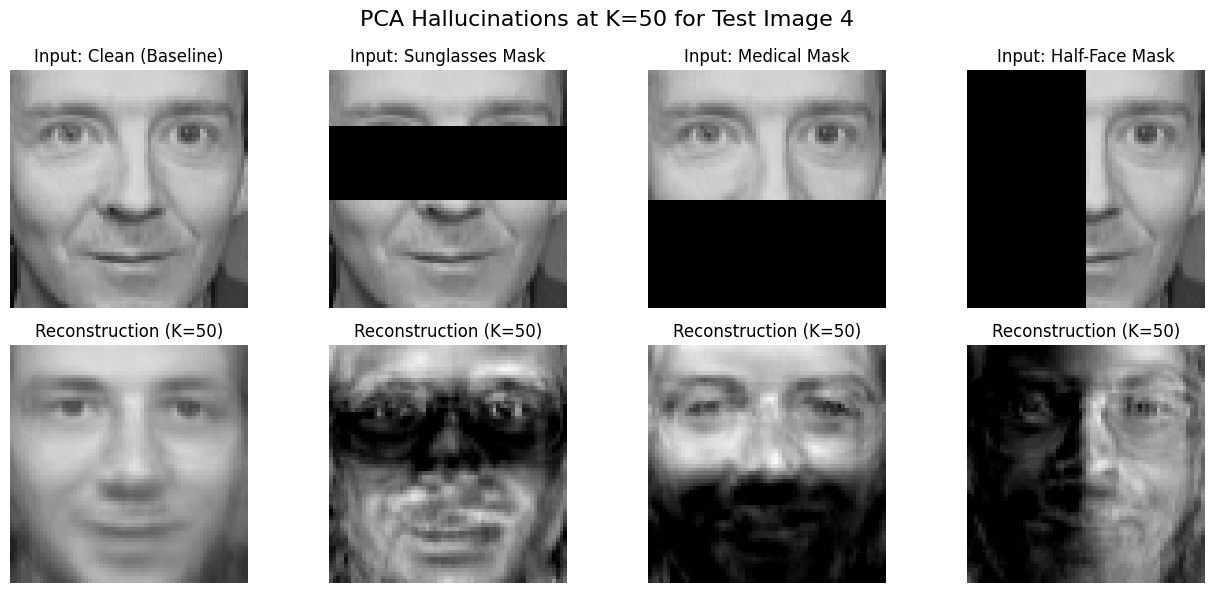

In [105]:
test_idx = 4
original_img = X_test[test_idx]

# 1. Re-create the masks for this single image (flattened to 4096)
img_sunglasses = original_img.copy().reshape(64, 64)
img_sunglasses[15:35, :] = 0.0 # Rows 15 to 35
img_sunglasses = img_sunglasses.flatten()

img_medical = original_img.copy().reshape(64, 64)
img_medical[35:64, :] = 0.0 # Rows 35 to 64
img_medical = img_medical.flatten()

img_half = original_img.copy().reshape(64, 64)
img_half[:, :32] = 0.0 # First 32 columns
img_half = img_half.flatten()

# Group them for easy looping
masked_images = [
    ("Clean (Baseline)", original_img),
    ("Sunglasses Mask", img_sunglasses),
    ("Medical Mask", img_medical),
    ("Half-Face Mask", img_half)
]

# 2. Use maximum K to force the highest-definition hallucinations
k = 50
U_k = eigenvectors_sorted[:, :k]

# ==========================================
# Plotting the Hallucinations
# ==========================================
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
fig.suptitle(f"PCA Hallucinations at K={k} for Test Image {test_idx}", fontsize=16, fontweight='normal')

for i, (title, img) in enumerate(masked_images):
    # --- Top Row: The Input Image ---
    axes[0, i].imshow(img.reshape(64, 64), cmap='gray', vmin=0.0, vmax=1.0)
    axes[0, i].set_title(f"Input: {title}")
    axes[0, i].axis('off')

    # --- Bottom Row: The Reconstruction ---
    # Center using the clean training mean
    img_centered = img - mean_face
    
    # Compress (Project) to get the corrupted weights
    weights = img_centered @ U_k
    
    # Reconstruct using the corrupted weights and add mean face back
    reconstructed = (weights @ U_k.T) + mean_face

    axes[1, i].imshow(reconstructed.reshape(64, 64), cmap='gray', vmin=0.0, vmax=1.0)
    axes[1, i].set_title(f"Reconstruction (K={k})")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

#### Random Sliding Block

We test the model's performance against missing data by sweeping through different block sizes. <br>
We dynamically generate slice coordinates on the fly for every single image using a random top-left corner and a specific block size parameter.

`image[row_start : row_start + size, col_start : col_start + size] = 0.0`

*   **How it Works:** Selects a specific square within the image matrix and forces those values to 0.0.
*   **Boundary safety:** The random starting coordinates are mathematically restricted (e.g., $64 - size + 1$) before the slice is made to guarantee the block never crosses the edges of the $64\times64$ grid.

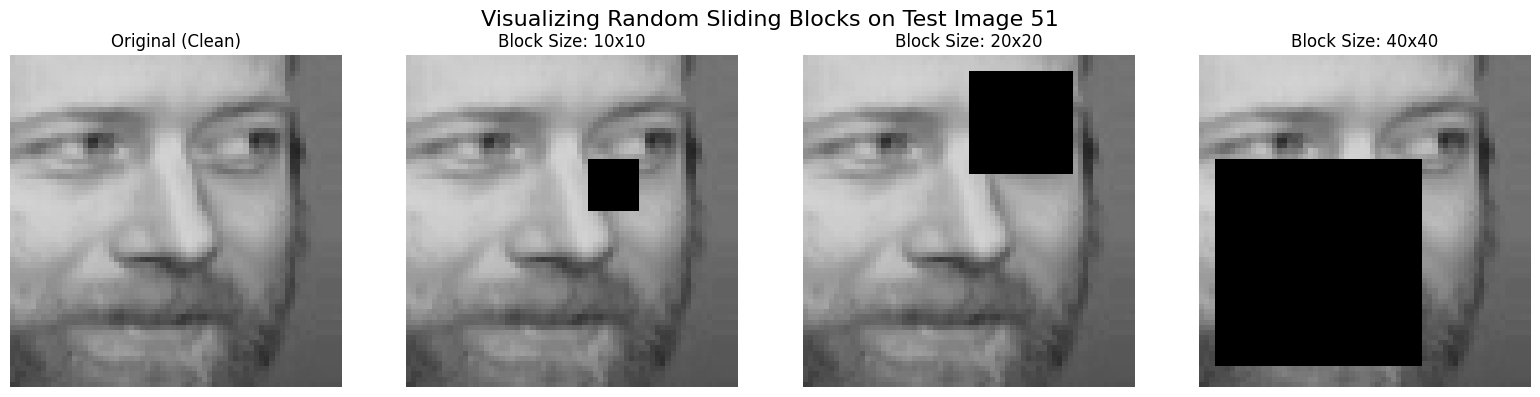

In [84]:
test_idx = 51
original_img = X_test[test_idx].reshape(64, 64)

# Define a few block sizes to visualize
sample_sizes = [10, 20, 40]
masked_images = []

# Set a random seed so the blocks appear in the exact same spot if you rerun it
np.random.seed(44) 

for size in sample_sizes:
    img_masked = original_img.copy()
    
    # Pick a random top-left corner that ensures the block fits inside the grid
    row_start = np.random.randint(0, 64 - size + 1)
    col_start = np.random.randint(0, 64 - size + 1)
    
    # Overwrite the random block with pure black (0.0)
    img_masked[row_start:row_start+size, col_start:col_start+size] = 0.0
    masked_images.append((img_masked, size))

# ==========================================
# Plotting the Masks
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f"Visualizing Random Sliding Blocks on Test Image {test_idx}", fontsize=16)

# We use vmin=0.0 and vmax=1.0 to prevent the grey-skin bug we fixed earlier!
axes[0].imshow(original_img, cmap='gray', vmin=0.0, vmax=1.0)
axes[0].set_title("Original (Clean)")
axes[0].axis('off')

for i, (img, size) in enumerate(masked_images):
    axes[i+1].imshow(img, cmap='gray', vmin=0.0, vmax=1.0)
    axes[i+1].set_title(f"Block Size: {size}x{size}")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

Plotting how the accuracy & MSE change with different block sizes of masks:

Evaluating random sliding block masks across increasing sizes...


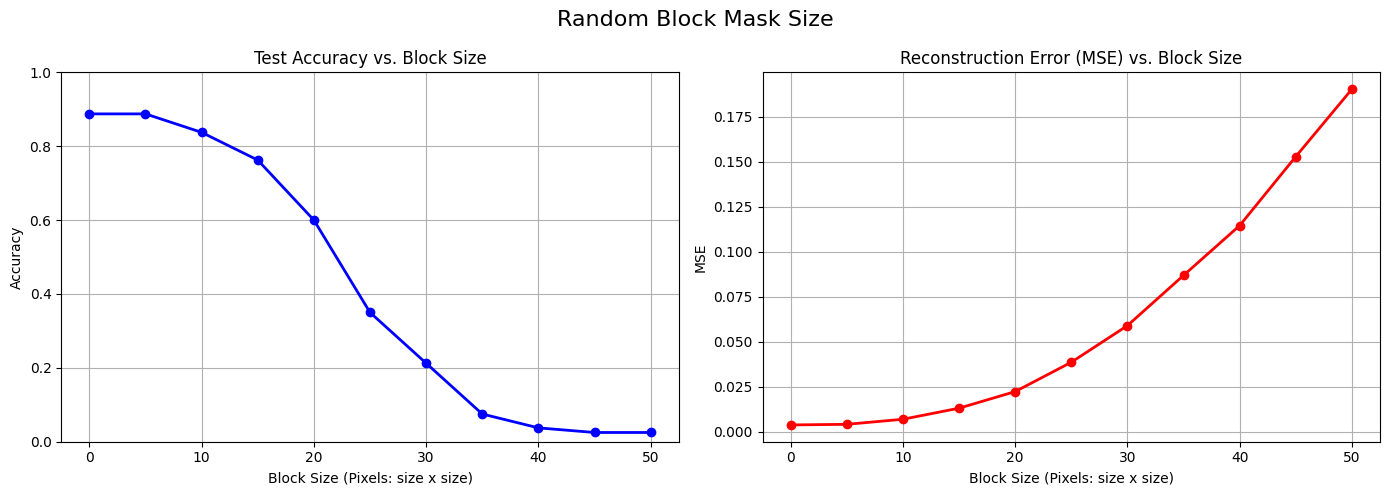

In [111]:
# 1. Define the block sizes (0 means clean, 50 means a massive 50x50 black square)
block_sizes = np.arange(0, 51, 5)

accuracies_block = []
mse_block = []

# Lock K=50 for the robustness test
k = 50
U_k = eigenvectors_sorted[:, :k]
W_train = X_train_centered @ U_k

# Set a random seed so your demo results are reproducible!
np.random.seed(42) 

print("Evaluating random sliding block masks across increasing sizes...")

for size in block_sizes:
    if size == 0:
        # Baseline (Clean Image)
        X_test_masked = X_test.copy()
    else:
        # Create a copy and reshape to 2D grids (64x64)
        X_test_masked = X_test.copy().reshape(-1, 64, 64)
        
        # Apply a random block to EVERY image in the test set
        for i in range(X_test_masked.shape[0]):
            # Pick a random top-left corner that ensures the block fits inside the grid
            row_start = np.random.randint(0, 64 - size + 1)
            col_start = np.random.randint(0, 64 - size + 1)
            
            # Overwrite the random block with black (0.0)
            X_test_masked[i, row_start:row_start+size, col_start:col_start+size] = 0.0
            
        # Flatten back to 4096 features for the math
        X_test_masked = X_test_masked.reshape(-1, 4096)
        
    # 2. Center the masked data using the clean training mean
    X_test_masked_centered = X_test_masked - mean_face
    
    # 3. Project into k-dimensional space
    W_test_masked = X_test_masked_centered @ U_k
    
    # 4. Nearest Neighbor Classification
    y_pred = []
    for test_vector in W_test_masked:
        distances = np.linalg.norm(W_train - test_vector, axis=1)
        closest_idx = np.argmin(distances)
        y_pred.append(y_train[closest_idx])
        
    acc = np.mean(np.array(y_pred) == y_test)
    accuracies_block.append(acc)
    
    # 5. Reconstruction Error (MSE) compared to the ORIGINAL clean test images
    X_test_reconstructed = (W_test_masked @ U_k.T) + mean_face
    mse = np.mean((X_test - X_test_reconstructed)**2)
    mse_block.append(mse)

# ==========================================
# Plotting the Results
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Random Block Mask Size", fontsize=16)

# Plot 1: Accuracy vs Block Size
ax1.plot(block_sizes, accuracies_block, marker='o', color='blue', linewidth=2)
ax1.set_title("Test Accuracy vs. Block Size")
ax1.set_xlabel("Block Size (Pixels: size x size)")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1.0)
ax1.grid(True)

# Plot 2: MSE vs Block Size
ax2.plot(block_sizes, mse_block, marker='o', color='red', linewidth=2)
ax2.set_title("Reconstruction Error (MSE) vs. Block Size")
ax2.set_xlabel("Block Size (Pixels: size x size)")
ax2.set_ylabel("MSE")
ax2.grid(True)

plt.tight_layout()
plt.show()

Plotting how the accuracy & MSE change with different block sizes of masks, as number of components $k$ varries:

In [112]:
# 1. Define the true high-res arrays (step size of 1)
block_sizes = np.arange(0, 51,5)
k_values = np.arange(1, 321)

# Initialize TWO 51x320 empty matrices
heatmap_acc = np.zeros((len(block_sizes), len(k_values)))
heatmap_mse = np.zeros((len(block_sizes), len(k_values)))

# Ensure training data is centered
X_train_centered = X_train - mean_face

# Pre-calculate the maximum 320-dimensional training weights
U_320 = eigenvectors_sorted[:, :320]
W_train_full = X_train_centered @ U_320

np.random.seed(42)
print("Generating Accuracy and MSE matrices...")

# Outer Loop: Apply the random block mask of a specific size
for row_idx, size in enumerate(block_sizes):
    
    if size == 0:
        X_test_masked = X_test.copy()
    else:
        X_test_masked = X_test.copy().reshape(-1, 64, 64)
        for i in range(X_test_masked.shape[0]):
            row_start = np.random.randint(0, 64 - size + 1)
            col_start = np.random.randint(0, 64 - size + 1)
            X_test_masked[i, row_start:row_start+size, col_start:col_start+size] = 0.0
        X_test_masked = X_test_masked.reshape(-1, 4096)
        
    X_test_masked_centered = X_test_masked - mean_face
    W_test_full = X_test_masked_centered @ U_320
    
    # Inner Loop: Evaluate across different K values
    for col_idx, k in enumerate(k_values):
        
        W_train_k = W_train_full[:, :k]
        W_test_k = W_test_full[:, :k]
        U_k = U_320[:, :k] # We also need the specific eigenvectors to reconstruct
        
        # 1. Nearest Neighbor Accuracy Calculation
        y_pred = []
        for test_vector in W_test_k:
            distances = np.linalg.norm(W_train_k - test_vector, axis=1)
            closest_idx = np.argmin(distances)
            y_pred.append(y_train[closest_idx])
            
        heatmap_acc[row_idx, col_idx] = np.mean(np.array(y_pred) == y_test)
        
        # 2. Reconstruction Error (MSE) Calculation vs ORIGINAL clean images
        X_test_reconstructed = (W_test_k @ U_k.T) + mean_face
        mse = np.mean((X_test - X_test_reconstructed)**2)
        heatmap_mse[row_idx, col_idx] = mse

Generating Accuracy and MSE matrices...


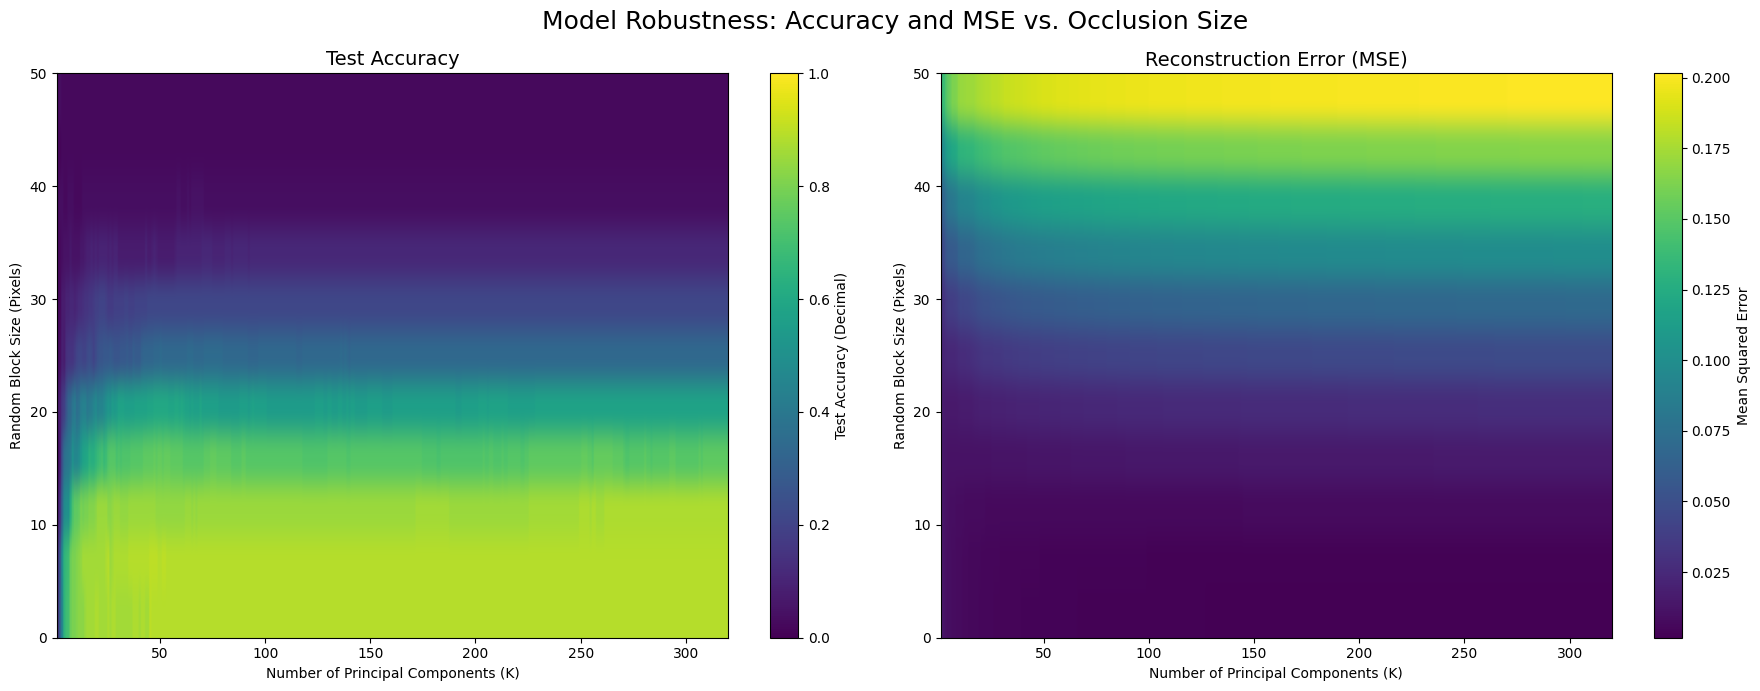

In [114]:
# ==========================================
# Plotting the Side-by-Side High-Res Heatmaps
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Model Robustness: Accuracy and MSE vs. Occlusion Size", fontsize=18, fontweight='normal')

# --- Plot 1: Accuracy Heatmap ---
im1 = ax1.imshow(heatmap_acc, cmap='viridis', aspect='auto', origin='lower',
                extent=[k_values.min(), k_values.max(), block_sizes.min(), block_sizes.max()],
                vmin=0.0, vmax=1.0)
fig.colorbar(im1, ax=ax1, label='Test Accuracy (Decimal)')
ax1.set_title("Test Accuracy", fontsize=14)
ax1.set_xlabel("Number of Principal Components (K)")
ax1.set_ylabel("Random Block Size (Pixels)")
ax1.grid(False)

# --- Plot 2: MSE Heatmap ---
# We use the 'viridis' colormap here so it visually stands apart from the accuracy graph
im2 = ax2.imshow(heatmap_mse, cmap='viridis', aspect='auto', origin='lower',
                extent=[k_values.min(), k_values.max(), block_sizes.min(), block_sizes.max()])
fig.colorbar(im2, ax=ax2, label='Mean Squared Error')
ax2.set_title("Reconstruction Error (MSE)", fontsize=14)
ax2.set_xlabel("Number of Principal Components (K)")
ax2.set_ylabel("Random Block Size (Pixels)")
ax2.grid(False)

plt.tight_layout()
plt.show()